# 01: Probability & Statistics Foundations

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.metrics import roc_auc_score

# Set plotting style for academic-looking charts
sns.set_theme(style="whitegrid")
np.random.seed(42) # For reproducibility

## 1a. Random Variables & Distributions

In our research, an LLM generating an answer is a random process. We model a single generation's factuality as a Bernoulli Random Variable:

- 1 = The model hallucinated (Failure)
- 0 = The model was truthful (Success)

If we evaluate $N$ prompts, the total number of hallucinations follows a Binomial Distribution.

### A few things that are easy to miss

For a Bernoulli outcome $X$ with $P(X=1)=p$:

$$
E[X] = p, \quad Var(X) = p(1-p)
$$

If we run $n$ independent prompts, the total number of hallucinations is:

$$
X = \sum_{i=1}^{n} X_i \sim \text{Binomial}(n, p)
$$

with

$$
E[X] = np, \quad Var(X) = np(1-p)
$$

This is the key reason benchmark results become more stable as the test set grows: the sample hallucination rate

$$
\hat{p} = \frac{X}{n}
$$

gets closer to the true rate $p$ as $n$ increases. This is the Law of Large Numbers.

A useful approximation: when $p$ is small and $n$ is large, the Binomial distribution is well approximated by a Poisson distribution with rate $\lambda = np$. This often shows up in rare-event settings like safety failures or hallucination spikes.


In [14]:

# The Bernoulli Trial (A single LLM answer)
# Let's assume the LLM has a true underlying hallucination rate of 20% (p = 0.2)
p_hallucination = 0.2
n_queries = 1000

# Simulate 1000 independent queries (1 = Hallucination, 0 = Truth)
llm_responses = np.random.binomial(n=1, p=p_hallucination, size=n_queries)
print("llm_responses shape :", llm_responses.shape)
print("llm response: \n", llm_responses)


print(f"Out of {n_queries} queries, the LLM hallucinated {llm_responses.sum()} times.")

llm_responses shape : (1000,)
llm response: 
 [0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 1 0 0 0 0 0 0 0 1 0 1 0 0 1
 0 0 1 0 0 0 0 1 0 0 0 1 1 0 0 1 1 0 1 1 0 1 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0
 1 0 0 1 0 0 0 0 0 0 1 0 0 1 0 1 0 0 0 0 1 0 0 0 1 0 1 0 0 0 0 0 0 0 0 0 0
 0 1 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 1 0 1 0 0 0 0 0 0 0 0 0 0 1 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 1 0 0 0 1
 1 0 0 1 0 0 1 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 1 0 0 0 0 1 1 0 0 0 0 0 0 0 0
 1 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 1 1 0 0 0 0 1 0 1 0 0 0 0 0 0 1 0 1 0 0 0
 1 0 0 1 0 0 1 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 1 0 0 1 1 0 0 0 0 0 0 0 0 1
 0 1 0 0 0 0 0 1 0 0 0 1 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 1 0 0 0 1 0 1 0 1
 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 1 1 0 0 0 0 0 1
 0 1 0 0 0 0 0 0 0 0 0 1 0 1 0 0 0 0 0 1 0 0 0 0 0 0 0 0 1 0 0 0 1 0 0 0 0
 0 0 0 1 0 0 0 0 0 0 0 0 0 0 1 0 0 1 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 1 0 0 0 1 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 1 0 1

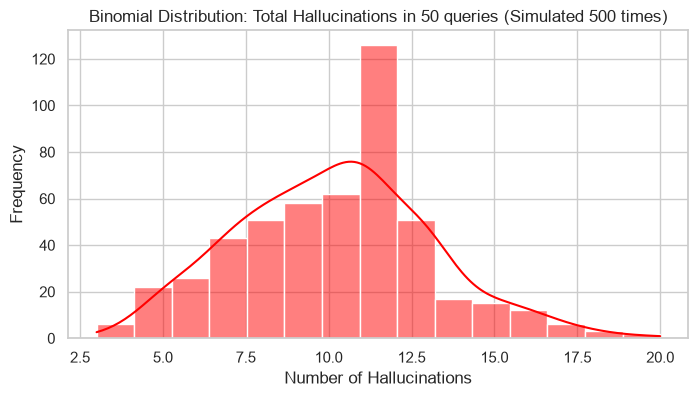

In [3]:
# The Binomial Distribution (Batch Evaluations)
# If we evaluate 500 different LLMs on 50 questions each, what does the distribution of errors look like?
n_questions_per_eval = 50
n_evaluations = 500

batch_errors = np.random.binomial(n=n_questions_per_eval, p=p_hallucination, size=n_evaluations)

plt.figure(figsize=(8, 4))
sns.histplot(batch_errors, bins=15, kde=True, color='red')
plt.title(f"Binomial Distribution: Total Hallucinations in {n_questions_per_eval} queries (Simulated {n_evaluations} times)")
plt.xlabel("Number of Hallucinations")
plt.ylabel("Frequency")
plt.show()

This is a histogram of simulated outcomes from a binomial process:

- Each of 50 questions is treated as a Bernoulli trial
- A hallucination is a “success” for the event we are counting
- The probability of a hallucination on any one question is $p = 0.2$
- We repeat that process 500 times

So each bar represents how many times a simulated model produced hallucinations in one run of 50 questions.

In math terms:

$$
X \sim \text{Binomial}(n=50, p=0.2)
$$

where $X$ is the number of hallucinations.

---

### How to read it

- The x-axis is the number of hallucinations, from about 0 to 20
- The y-axis is how often that count occurred across the 500 simulations
- The red curve is a smooth density estimate (KDE), showing the overall shape

The distribution is centered near:

$$
\mu = np = 50 \times 0.2 = 10
$$

So the most common outcomes are around 8–12 hallucinations per 50-question batch.

The spread is also what you’d expect from a binomial distribution:

$$
\sigma = \sqrt{np(1-p)} = \sqrt{50 \times 0.2 \times 0.8} \approx 2.8
$$

That’s why values far below 5 or above 15 are less common.

---

### Why it looks like this

This is the classic shape of a binomial distribution:

- it is roughly bell-shaped
- centered around the mean
- slightly skewed because $p=0.2$ is not 0.5
- taller near the center and lower in the tails

The histogram is not perfectly smooth because it is based on only 500 simulated runs, but the overall pattern matches the theoretical binomial model well.

> In plain language: most “50-question evaluations” produce around 10 hallucinations, with fewer cases producing very low or very high counts.

## 1b. Variance, Standard Error, and the Central Limit Theorem (CLT)

Variance, standard error, and the Central Limit Theorem (CLT) help measure how reliable a large language model's (LLM) benchmark score is by calculating uncertainty and error bars. 

### Variance in LLM Evaluations 
- **Definition:** Variance measures how much individual test results spread out around the average score. 
- **In LLMs:** Each test prompt in an evaluation dataset (like accuracy on a single question being 0 or 1) has its own variance. 
- **Impact:** Binary pass/fail metrics have a variance determined directly by the model's average accuracy rate.

### Standard Error 
- **Definition:** Standard error is the standard deviation of a sample's average score, showing how much that average bounces around across different random test sets. 
- **Formula:** It equals the population standard deviation divided by the square root of the sample size ($n$). 
- **In LLMs:** As you test more prompts, the standard error shrinks, meaning your accuracy estimate for the LLM becomes more precise.

### Central Limit Theorem (CLT) in LLMs 
- **Definition:** CLT states that the average of a large enough sample of data will form a normal bell-curve distribution, no matter what the individual data points look like. 
- **In LLMs:** When evaluating a model on large benchmarks (like MMLU or GSM8K with thousands of test questions), CLT lets researchers build standard confidence intervals and error bars. 
- **The Catch:** CLT fails to give accurate error estimates for small or specialized LLM benchmarks because the sample size is too low to form a reliable normal curve.

If you want, tell me:What benchmark size are you working with?Are you evaluating binary accuracy or a continuous score?I can suggest the best uncertainty quantification method for your project. 
AI responses may include mistakes.

[1] https://arxiv.org/pdf/2503.01747

[2] https://icml.cc/virtual/2025/poster/40132

Why is a test set of 50 examples not enough to publish a paper? Because of Variance.
The Central Limit Theorem (CLT) proves that as we increase our sample size, the distribution of our estimated hallucination rate will form a tight Normal Distribution around the true hallucination rate, shrinking our Standard Error.

A practical rule of thumb: for a binary classifier or hallucination detector, the observed error rate is itself a random variable. If the true hallucination rate is $p$, then the standard error of the estimate is:

$$
SE(\hat{p}) = \sqrt{\frac{p(1-p)}{n}}
$$

This tells us why small benchmarks are noisy. For example, with $n=50$ and $p=0.2$:

$$
SE(\hat{p}) \approx \sqrt{\frac{0.2 \cdot 0.8}{50}} \approx 0.056
$$

That means a measured hallucination rate may easily bounce around by several percentage points just from randomness.

This is exactly why we use confidence intervals, repeated trials, and bootstrap resampling when reporting benchmark reliability.


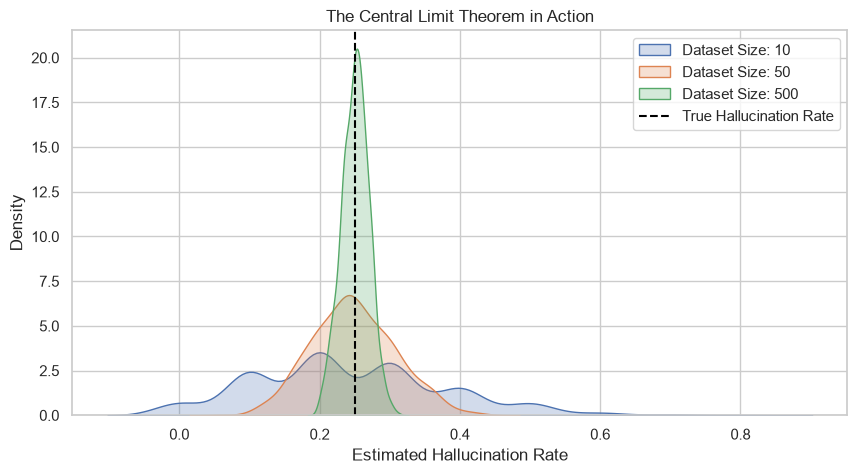

In [5]:
# Let's simulate why small evaluation sets are dangerous
true_p = 0.25 # True hallucination rate is 25%

sample_sizes = [10, 50, 500] # Number of prompts in our evaluation dataset
n_experiments = 1000 # How many times we repeat the evaluation

plt.figure(figsize=(10, 5))

for size in sample_sizes:
    # Run the experiment 1000 times for each sample size
    # np.mean calculates the estimated hallucination rate for each experiment
    experiment_means = [np.mean(np.random.binomial(1, true_p, size)) for _ in range(n_experiments)]
    sns.kdeplot(experiment_means, label=f'Dataset Size: {size}', fill=True)

plt.axvline(true_p, color='black', linestyle='--', label='True Hallucination Rate')
plt.title("The Central Limit Theorem in Action")
plt.xlabel("Estimated Hallucination Rate")
plt.ylabel("Density")
plt.legend()
plt.show()

# Takeaway: With only 10 examples, you might randomly measure a 0% or 50% hallucination rate.
# With 500 examples, your estimate is tightly clustered around the true 25%.

## 1c. Bootstrap Resampling & Confidence Intervals

Often, we evaluate metrics whose variance is mathematically hard to compute (like AUROC or F1 score). Bootstrapping is a brute-force statistical method: we sample our own dataset with replacement thousands of times to estimate our uncertainty.

A related idea that is often worth mentioning is statistical power. Even if a method is truly better, a small dataset may not detect that difference reliably. Power is the probability of correctly finding a real effect. In LLM evaluation, low power often means you fail to detect meaningful model improvements because the sample is too small or the effect size is too small.

This is why many leaderboard-style comparisons should report:

- effect size,
- confidence intervals,
- sample size,
- and multiple-comparison correction when testing many variants.

For LLM research, a result can be statistically significant but practically tiny. The more interesting question is often not just “is it different?” but “is it different enough to matter?”


This Python code evaluates a hallucination detector model and uses bootstrapping to measure its statistical stability.

### 1. Data Simulation

* Creates a toy dataset of 100 queries containing 20 hallucinations (label 1) and 80 truthful answers (label 0).
* Simulates model confidence scores using two distinct normal distributions, forcing higher scores for hallucinations and lower scores for truthful text.
* Calculates the Baseline AUROC score to evaluate how effectively the model separates the two classes.

### 2. Bootstrapping From Scratch

* Runs 1,000 iterations to simulate how the model might perform on slightly different variations of the data.
* In each iteration, it creates a new dataset by sampling with replacement (randomly picking 100 rows from the original data, where some rows repeat and others are skipped).
* Recalculates and stores the AUROC score for each of the 1,000 resampled datasets.

### 3. Confidence Interval & Visualization

* Extracts the 2.5th and 97.5th percentiles from the 1,000 bootstrap scores to calculate a 95% Confidence Interval. This indicates the statistical range where the model's true performance likely falls.
* Plots a distribution histogram using seaborn and matplotlib to visually map out the baseline score against the calculated reliability boundaries.

In [16]:
# Toy AUROC Calculation
# 100 queries: 20 hallucinations (label 1), 80 truthful (label 0)
y_true = np.array([1]*20 + [0]*80)

# Our single-pass detector outputs a confidence score (0.0 to 1.0)
# We simulate good (but imperfect) predictions
y_scores = np.where(y_true == 1, np.random.normal(0.7, 0.2, 100), np.random.normal(0.3, 0.2, 100))
print("outputs from a single pass: \n",y_scores)

# Baseline AUROC
baseline_auroc = roc_auc_score(y_true, y_scores)
print(f"\nBaseline AUROC: {baseline_auroc:.3f}")

outputs from a single pass: 
 [ 0.77383197  0.48977346  0.91417572  0.94183451  0.88501546  0.4950313
  1.10976109  0.40458988  0.70398994  0.81462613  0.52104414  0.79192028
  1.15484897  1.10024147  0.69910194  0.82819205  0.96644433  1.01067897
  0.74302795  0.94175093 -0.09167603  0.04517588  0.36087361  0.2931369
  0.67509033  0.56715561  0.53482517  0.28365797  0.19842008  0.20718332
  0.49696142  0.3142868   0.39428159  0.2906629   0.47436503  0.11708705
  0.34899217  0.2097864   0.20377382  0.02954694 -0.04966197  0.00603733
  0.55926882  0.57244942  0.18289657  0.09253632  0.42960714  0.48256927
  0.36473501  0.62585184  0.33714694  0.16712956  0.20510013  0.31904018
  0.24900514  0.55367038  0.48607789  0.4236216   0.41661886  0.57701069
  0.22337102  0.67582079  0.19427639  0.25429789  0.31122984  0.48677184
  0.42978436  0.39405463  0.39391699  0.13303262  0.64335189  0.16351492
  0.27661104  0.46951799  0.14002282  0.0381916   0.41927982  0.11781316
  0.13738784  0.1152192

In [17]:
# --- Bootstrap from Scratch ---
n_iterations = 1000
bootstrap_aurocs = []

for _ in range(n_iterations):
    # Sample WITH replacement from our dataset
    indices = np.random.choice(range(len(y_true)), size=len(y_true), replace=True)
    y_true_boot = y_true[indices]
    y_scores_boot = y_scores[indices]

    # We must ensure both classes exist in the bootstrap sample to calculate AUROC
    if len(np.unique(y_true_boot)) > 1:
        score = roc_auc_score(y_true_boot, y_scores_boot)
        bootstrap_aurocs.append(score)

# Calculate 95% Confidence Interval (2.5th and 97.5th percentiles)
lower_bound = np.percentile(bootstrap_aurocs, 2.5)
upper_bound = np.percentile(bootstrap_aurocs, 97.5)

print(f"95% Confidence Interval: [{lower_bound:.3f}, {upper_bound:.3f}]")

95% Confidence Interval: [0.890, 0.988]


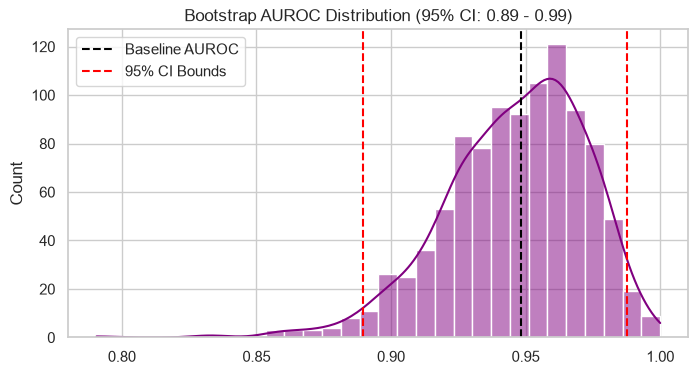

In [18]:
# Plot the Bootstrap Distribution
plt.figure(figsize=(8, 4))
sns.histplot(bootstrap_aurocs, bins=30, kde=True, color='purple')
plt.axvline(baseline_auroc, color='black', linestyle='--', label='Baseline AUROC')
plt.axvline(lower_bound, color='red', linestyle='--', label='95% CI Bounds')
plt.axvline(upper_bound, color='red', linestyle='--')
plt.title(f"Bootstrap AUROC Distribution (95% CI: {lower_bound:.2f} - {upper_bound:.2f})")
plt.legend()
plt.show()

In [ ]:
from sklearn.metrics import precision_recall_curve, auc

# Simulate an Imbalanced Dataset
# 1000 queries: 50 hallucinations (5%), 950 truthful (95%)
y_true_imbalanced = np.array([1]*50 + [0]*950)

# Simulate a mediocre detector
# It catches some truths, but often flags truths as hallucinations (False Positives)
y_scores_imbalanced = np.where(
    y_true_imbalanced == 1,
    np.random.normal(0.6, 0.2, 1000),
    np.random.normal(0.4, 0.3, 1000)
)

# Calculate AUROC (Can be deceptively high)
roc_auc_imbal = roc_auc_score(y_true_imbalanced, y_scores_imbalanced)

# Calculate AUPRC (More honest for rare events)
precision, recall, _ = precision_recall_curve(y_true_imbalanced, y_scores_imbalanced)
pr_auc_imbal = auc(recall, precision)

print(f"AUROC Score: {roc_auc_imbal:.3f} (Looks great!)")
print(f"AUPRC Score: {pr_auc_imbal:.3f} (Reveals the detector struggles with precision!)")

AUROC Score: 0.698 (Looks great!)
AUPRC Score: 0.077 (Reveals the detector struggles with precision!)


**Why AUROC is 0.698**

An AUROC of 0.500 is random guessing. Scoring 0.698 means that if you randomly pick one actual hallucination and one truthful answer, the detector will correctly give the hallucination a higher risk score 69% of the time. To an undergrad, 69% sounds like "okay, the model is learning something, it's a decent baseline."

**Why AUPRC is 0.077**

This is the reality check. In a dataset where only 5% of the answers are hallucinations, the baseline AUPRC for a random guess is 0.050.
Your detector scored 0.077. This means despite the "okay-looking" AUROC, the detector is practically useless in the real world. It is throwing so many False Positives (flagging perfectly truthful text as hallucinations) that its precision is completely destroyed.

`Note:` The value change because we are randomly generating data here

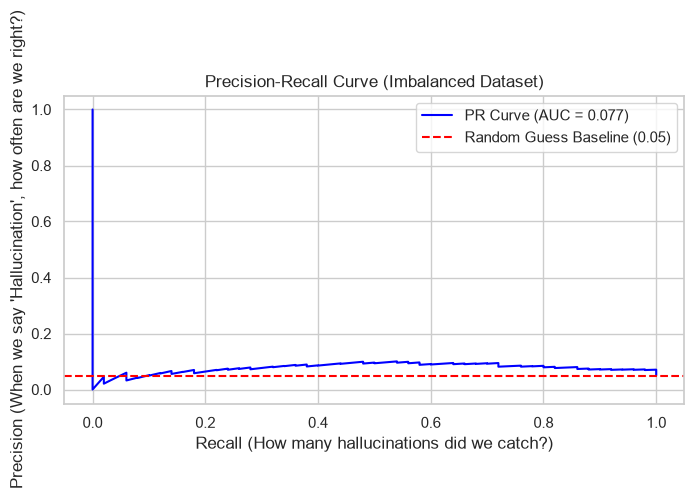

In [22]:
# Plotting the Precision-Recall Curve
plt.figure(figsize=(8, 4))
plt.plot(recall, precision, color='blue', label=f'PR Curve (AUC = {pr_auc_imbal:.3f})')
# Baseline AUPRC for random guessing is equal to the minority class ratio (0.05)
plt.axhline(y=0.05, color='red', linestyle='--', label='Random Guess Baseline (0.05)')
plt.title("Precision-Recall Curve (Imbalanced Dataset)")
plt.xlabel("Recall (How many hallucinations did we catch?)")
plt.ylabel("Precision (When we say 'Hallucination', how often are we right?)")
plt.legend()
plt.show()

**Why AUPRC matters for LLMs:** If your LLM only hallucinates 5% of the time, the dataset is heavily imbalanced. A detector that just flags 30% of everything as a hallucination might achieve a high AUROC because it successfully identifies the massive True Negative class (the truthful statements). However, its Precision will be terrible because it generates too many False Positives.

The Precision-Recall Curve (AUPRC) ignores True Negatives. It only measures how effectively you find the rare hallucinations without crying wolf. In our Cascade research, high precision is required to avoid sending truthful answers to the expensive Stage 3 verification layer.

## 1d. Hypothesis Testing: Is Detector A actually better?

Suppose your new Cascade Detector gets an AUROC of 0.85, and the baseline Log-Prob threshold gets 0.82. Is your cascade actually better, or did it just get lucky on this specific dataset?

We use a Paired t-test (if differences are normally distributed) or a Wilcoxon signed-rank test (non-parametric, safer for ML metrics).

In [9]:
# Simulate error rates for 30 different prompt batches
# Lower is better (Cost-efficient cascade vs Baseline)
baseline_errors = np.random.normal(loc=0.15, scale=0.04, size=30)
cascade_errors = baseline_errors - np.random.normal(loc=0.02, scale=0.03, size=30) # Cascade is slightly better

print("Baseline Errors: ", baseline_errors)
print("\nCascade Errors: ", cascade_errors)

Baseline Errors:  [0.1670131  0.13807438 0.13217236 0.16266764 0.19194648 0.14902693
 0.11064942 0.11631808 0.198548   0.20382157 0.20114762 0.06935443
 0.12476696 0.06509622 0.11667313 0.22697392 0.1138339  0.14930742
 0.15836419 0.09599566 0.27631364 0.14235793 0.19756548 0.14506437
 0.18329601 0.13395232 0.1859328  0.08630448 0.15828865 0.13969591]

Cascade Errors:  [0.14413377 0.11982269 0.1126489  0.16013867 0.18550734 0.09197828
 0.03728152 0.10422084 0.20080201 0.20685026 0.19190602 0.02616935
 0.13309991 0.05934307 0.12378243 0.21470344 0.03075564 0.13654672
 0.20094704 0.07827716 0.27546438 0.10899351 0.18835432 0.15182339
 0.19420187 0.07905722 0.15823421 0.06189636 0.18977323 0.10760514]


In [10]:
# Paired t-test
t_stat, p_value_t = stats.ttest_rel(baseline_errors, cascade_errors)

# Wilcoxon signed-rank test (Safer for non-normal ML metrics)
w_stat, p_value_w = stats.wilcoxon(baseline_errors, cascade_errors)

print(f"Mean Baseline Error: {np.mean(baseline_errors):.3f}")
print(f"Mean Cascade Error:  {np.mean(cascade_errors):.3f}")
print("-" * 30)
print(f"Paired t-test p-value: {p_value_t:.4f}")
print(f"Wilcoxon p-value:      {p_value_w:.4f}")

if p_value_w < 0.05:
    print("Conclusion: The Cascade is statistically significantly better (p < 0.05).")
else:
    print("Conclusion: The difference is not statistically significant. We cannot claim the Cascade is better.")

Mean Baseline Error: 0.151
Mean Cascade Error:  0.136
------------------------------
Paired t-test p-value: 0.0044
Wilcoxon p-value:      0.0024
Conclusion: The Cascade is statistically significantly better (p < 0.05).


## 1e. Multiple Comparisons (The Bonferroni Correction)

If we test 10 different single-pass signals (Length, Entropy, Log-probs, Hedging, etc.) to see which one detects hallucinations best, standard math breaks down. If we use a significance threshold of $p < 0.05$, there is a 5% chance of finding a "significant" signal entirely by random noise. If we test 10 signals, a false positive is highly likely.

We fix this with the Bonferroni Correction: divide your target p-value by the number of tests.

In [11]:
num_detectors_tested = 10
standard_p_threshold = 0.05

# Bonferroni Correction
adjusted_p_threshold = standard_p_threshold / num_detectors_tested

print(f"Standard threshold for claiming success: {standard_p_threshold}")
print(f"Bonferroni-corrected threshold:          {adjusted_p_threshold}")

# Simulated p-values for our 10 linguistic features
# Imagine one feature got a p-value of 0.03.
simulated_p_values = [0.45, 0.89, 0.03, 0.12, 0.77, 0.91, 0.22, 0.54, 0.31, 0.68]

print("\n--- Evaluation ---")
for i, p in enumerate(simulated_p_values):
    if p < standard_p_threshold and p >= adjusted_p_threshold:
        print(f"Detector {i+1} (p={p}): Significant under standard math, but FAILS Bonferroni correction (False Positive Risk!)")
    elif p < adjusted_p_threshold:
        print(f"Detector {i+1} (p={p}): Truly Significant!")

Standard threshold for claiming success: 0.05
Bonferroni-corrected threshold:          0.005

--- Evaluation ---
Detector 3 (p=0.03): Significant under standard math, but FAILS Bonferroni correction (False Positive Risk!)
